In [8]:
%pip install pandas matplotlib

  Using cached matplotlib-3.10.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
Using cached matplotlib-3.10.3-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 17.1 MB/s eta 0:00:00
Using cached kiwisolver-1.4.8-cp312-cp312-macosx_11_0_arm64.whl (65 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 36.4 MB/s eta 0:00:00
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]
Note: you may need to restart the kernel to use updated packages.


,Quantity_balances,Quantity_taxlots,Quantity_diff
Time,,,
2018-02-03,18.297123,19.342123,-1.045000
2018-07-13,21.113062,14.190741,6.922321
2018-07-14,21.098262,14.175941,6.922321
2018-07-17,20.908262,13.985941,6.922321
2018-07-20,20.847262,13.924941,6.922321
...,...,...,...
2025-04-18,0.190956,4.517305,-4.326349
2025-05-01,-0.008105,4.318244,-4.326349
2025-05-08,-0.008105,4.318244,-4.326349


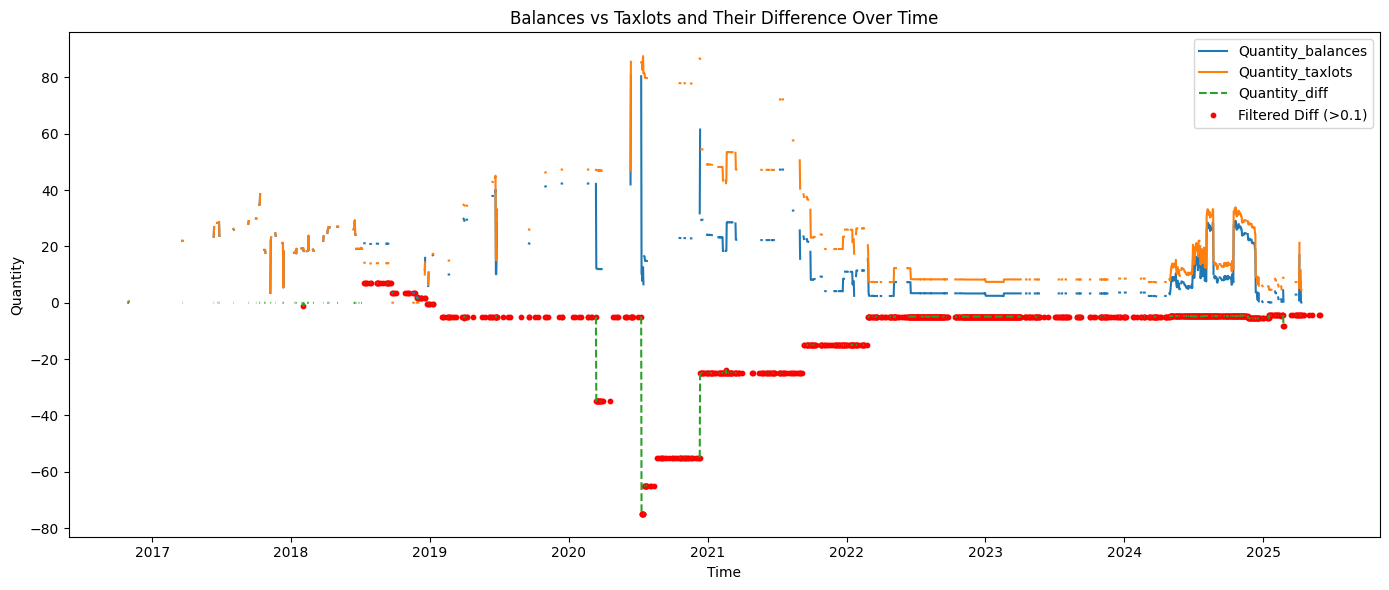

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV files
balances_df = pd.read_csv('../total_quantity_history_balances.csv')
taxlots_df = pd.read_csv('../total_quantity_history_taxlots.csv')

# Ensure the time column is in datetime format
balances_df['Time'] = pd.to_datetime(balances_df['Time'])
taxlots_df['Time'] = pd.to_datetime(taxlots_df['Time'])
balances_df_monthly = balances_df.resample('D', on='Time').last()
taxlots_df_monthly = taxlots_df.resample('D', on='Time').last()

# Merge the two DataFrames on the 'Time' column
merged_df = pd.merge(balances_df_monthly, taxlots_df_monthly, on='Time', suffixes=('_balances', '_taxlots'))

# Add a new column for the difference between the 'Quantity' columns
merged_df['Quantity_diff'] = merged_df['Quantity_balances'] - merged_df['Quantity_taxlots']

filtered_df = merged_df[merged_df['Quantity_diff'].abs() > 0.1]  # Filter rows where the difference is greater than 1.0
display(filtered_df)

plt.figure(figsize=(14, 6))
plt.plot(merged_df.index, merged_df['Quantity_diff'], label='Quantity_diff', linestyle='--')
plt.scatter(filtered_df.index, filtered_df['Quantity_diff'], color='red', label='Filtered Diff (>0.1)', s=10)
plt.xlabel('Time')
plt.ylabel('Quantity')
plt.title('Balances vs Taxlots and Their Difference Over Time')
plt.legend()
plt.tight_layout()
plt.show()